In [4]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import os
os.chdir("/home/piai/Desktop/git/1 Big Data 분석 기초")
# 폰트
matplotlib.rc('font', family = "NanumSquare")
#음수
matplotlib.rc('axes', unicode_minus=False)

In [5]:
df_fitness = pd.read_csv("FITNESS.csv", encoding = 'euc-kr')
df_currency = pd.read_csv("환율.csv", parse_dates = ["APPL_DATE"])

display(df_fitness.head())
display(df_currency.head())

,NAME,GENDER,AGE,AGEGROUP,WEIGHT,OXY,RUNTIME,RUNPULSE,RSTPULSE,MAXPULSE
0,Donna,여성,42,40대,68.15,59.571,8.17,166,40,172
1,Gracie,여성,38,30대,81.87,60.055,8.63,170,48,186
2,Luanne,여성,43,40대,85.84,54.297,8.65,156,45,168
3,Mimi,여성,50,50대,70.87,54.625,8.92,146,48,155
4,Chris,남성,49,40대,81.42,49.156,8.95,180,44,185


,CURRENCY,APPL_DATE,STD_RATE,USD_CONV_DATE
0,CNY,2016-01-01,181.48,0.1541
1,JPY,2016-01-01,976.99,0.8294
2,USD,2016-01-01,1178.00,1.0000
3,CNY,2016-01-02,181.48,0.1541
4,JPY,2016-01-02,976.99,0.8294


<Axes: xlabel='GENDER', ylabel='count'>

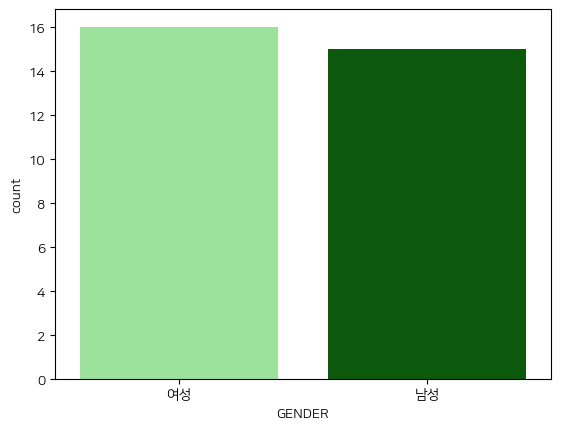

In [36]:
sns.countplot(x='GENDER', data=df_fitness, palette = ['lightgreen','darkgreen'])

<Axes: xlabel='AGEGROUP', ylabel='count'>

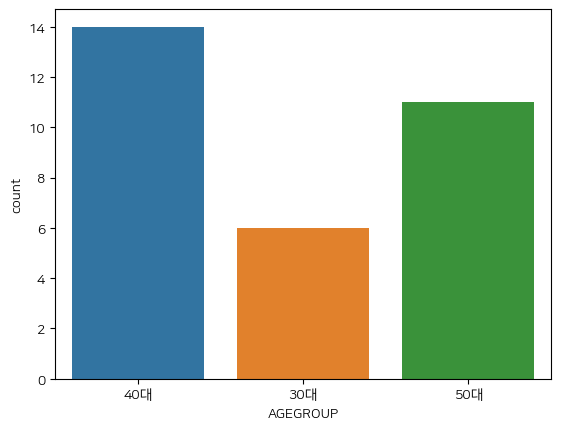

In [7]:
sns.countplot(x='AGEGROUP', data=df_fitness)

<Axes: xlabel='AGEGROUP', ylabel='count'>

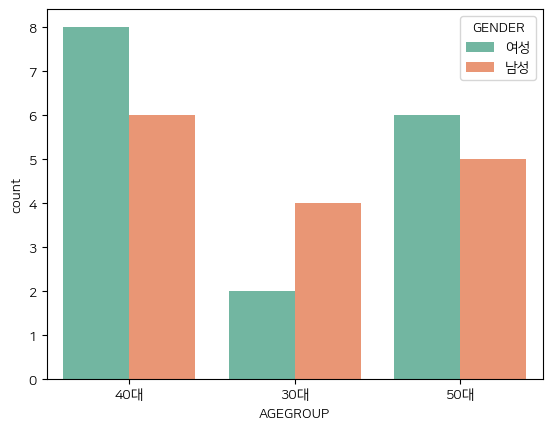

In [44]:
sns.countplot(x='AGEGROUP', hue = "GENDER", data=df_fitness, palette ='Set2')

<Axes: xlabel='OXY', ylabel='Count'>

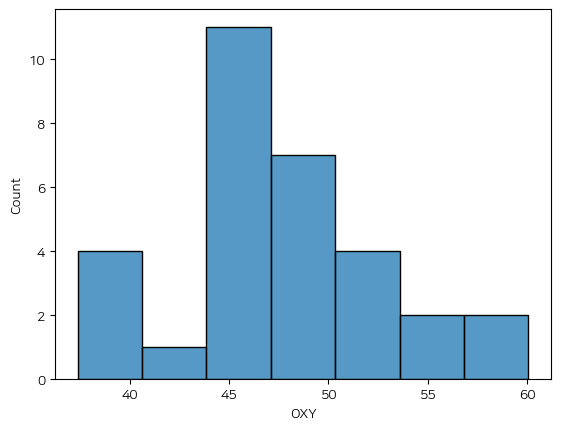

In [12]:
sns.histplot(data = df_fitness, x = "OXY")

array([[<Axes: title={'center': 'AGE'}>,
        <Axes: title={'center': 'WEIGHT'}>,
        <Axes: title={'center': 'OXY'}>],
       [<Axes: title={'center': 'RUNTIME'}>,
        <Axes: title={'center': 'RUNPULSE'}>,
        <Axes: title={'center': 'RSTPULSE'}>],
       [<Axes: title={'center': 'MAXPULSE'}>, <Axes: >, <Axes: >]],
      dtype=object)

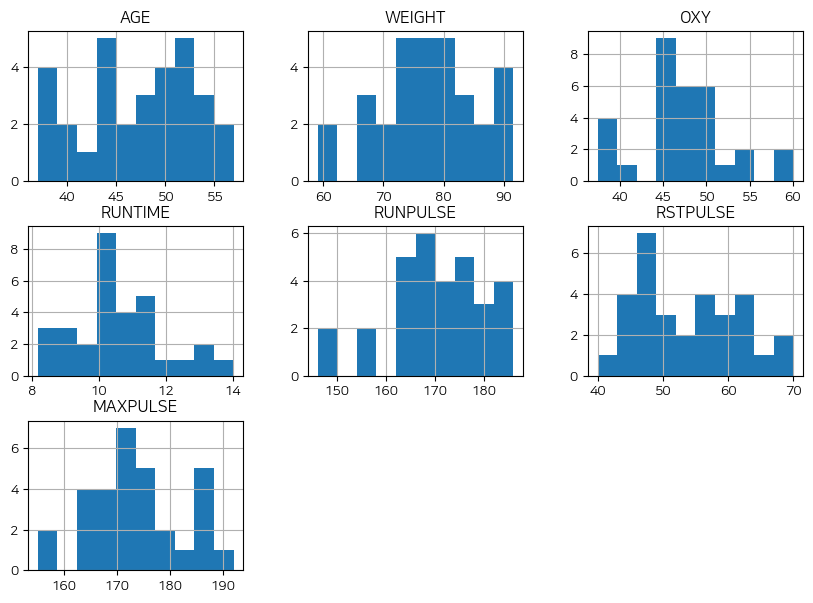

In [14]:
df_fitness.hist(figsize = (10,7))

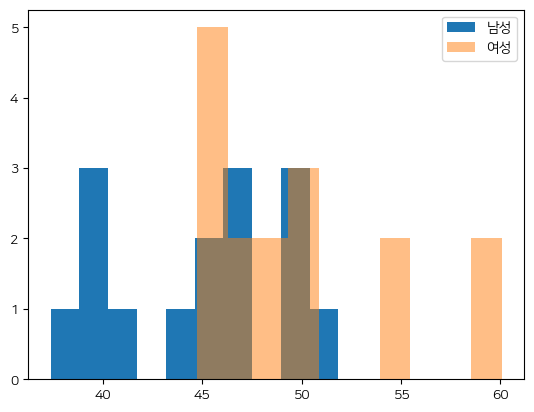

In [19]:
plt.hist(df_fitness[df_fitness["GENDER"] == "남성"]["OXY"],label = "남성", alpha = 1.0)
plt.hist(df_fitness[df_fitness["GENDER"] == "여성"]["OXY"],label = "여성", alpha = 0.5)
plt.legend()

<Axes: xlabel='OXY', ylabel='Count'>

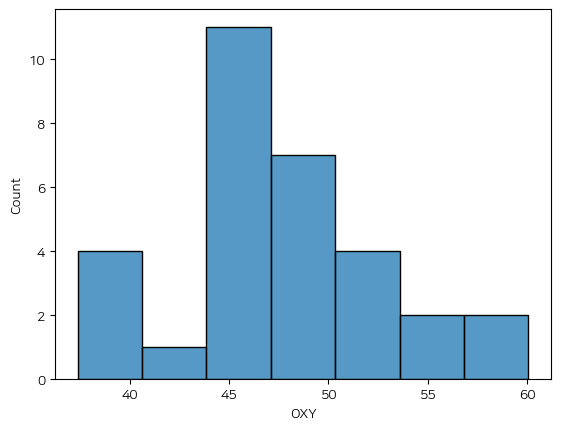

In [20]:
sns.histplot(data = df_fitness, x = "OXY")

<Axes: xlabel='OXY', ylabel='Count'>

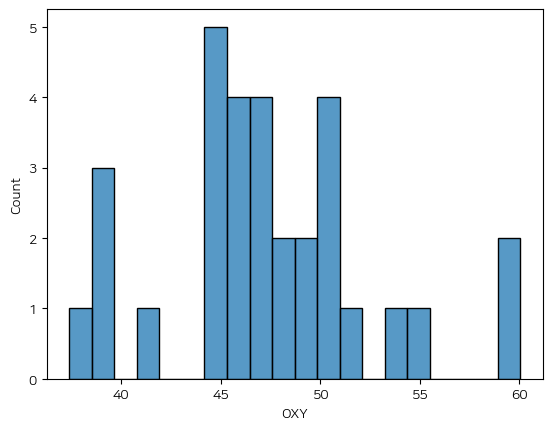

In [21]:
sns.histplot(data = df_fitness, x = "OXY", bins = 20)

<Axes: xlabel='AGEGROUP', ylabel='OXY'>

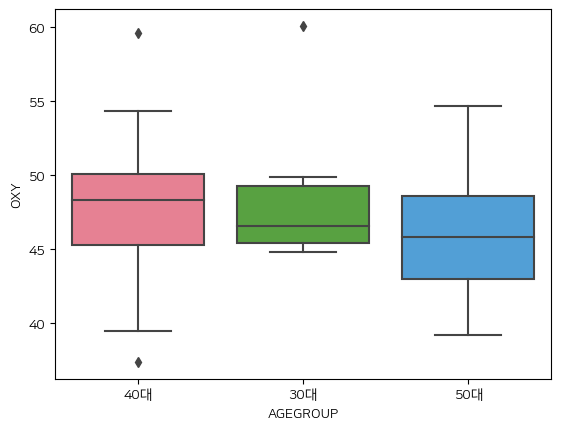

In [47]:
sns.boxplot(y = 'OXY', x = 'AGEGROUP', data = df_fitness, palette = 'husl')

<Axes: xlabel='GENDER', ylabel='OXY'>

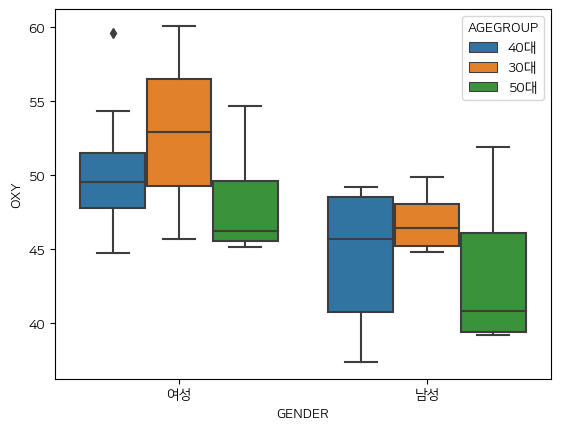

In [24]:
sns.boxplot(y = 'OXY', x = 'GENDER', hue = 'AGEGROUP', data = df_fitness)

<Axes: >

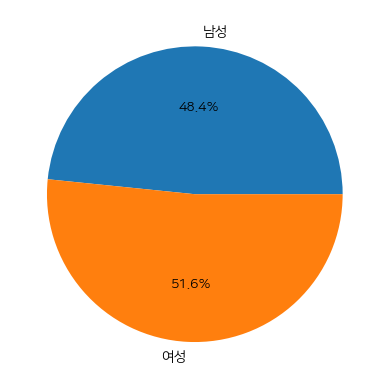

In [50]:
df_count = df_fitness.groupby(["GENDER"]).size()
df_count.plot.pie(y = "OXY",autopct = "%.1f%%")

<Axes: >

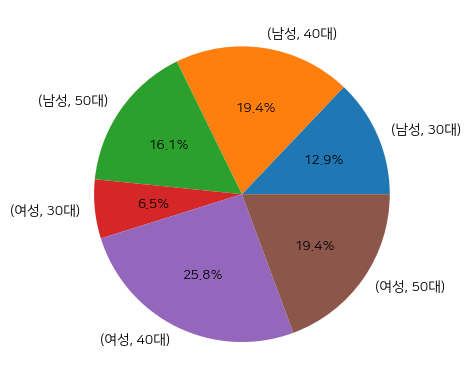

In [54]:
df_count = df_fitness.groupby(["GENDER","AGEGROUP"]).size()
df_count.plot.pie(y = "OXY",autopct = "%.1f%%")

<Axes: xlabel='RUNTIME', ylabel='OXY'>

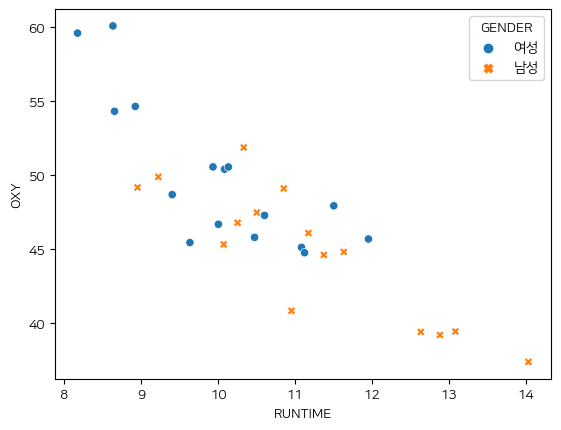

In [57]:
sns.scatterplot(x = "RUNTIME", y = "OXY", hue = "GENDER", style = "GENDER", data = df_fitness)

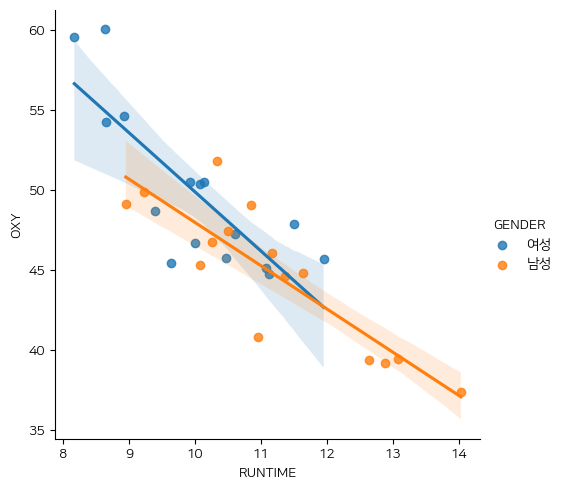

In [58]:
sns.lmplot(data = df_fitness, x = "RUNTIME", y = "OXY", hue = "GENDER")

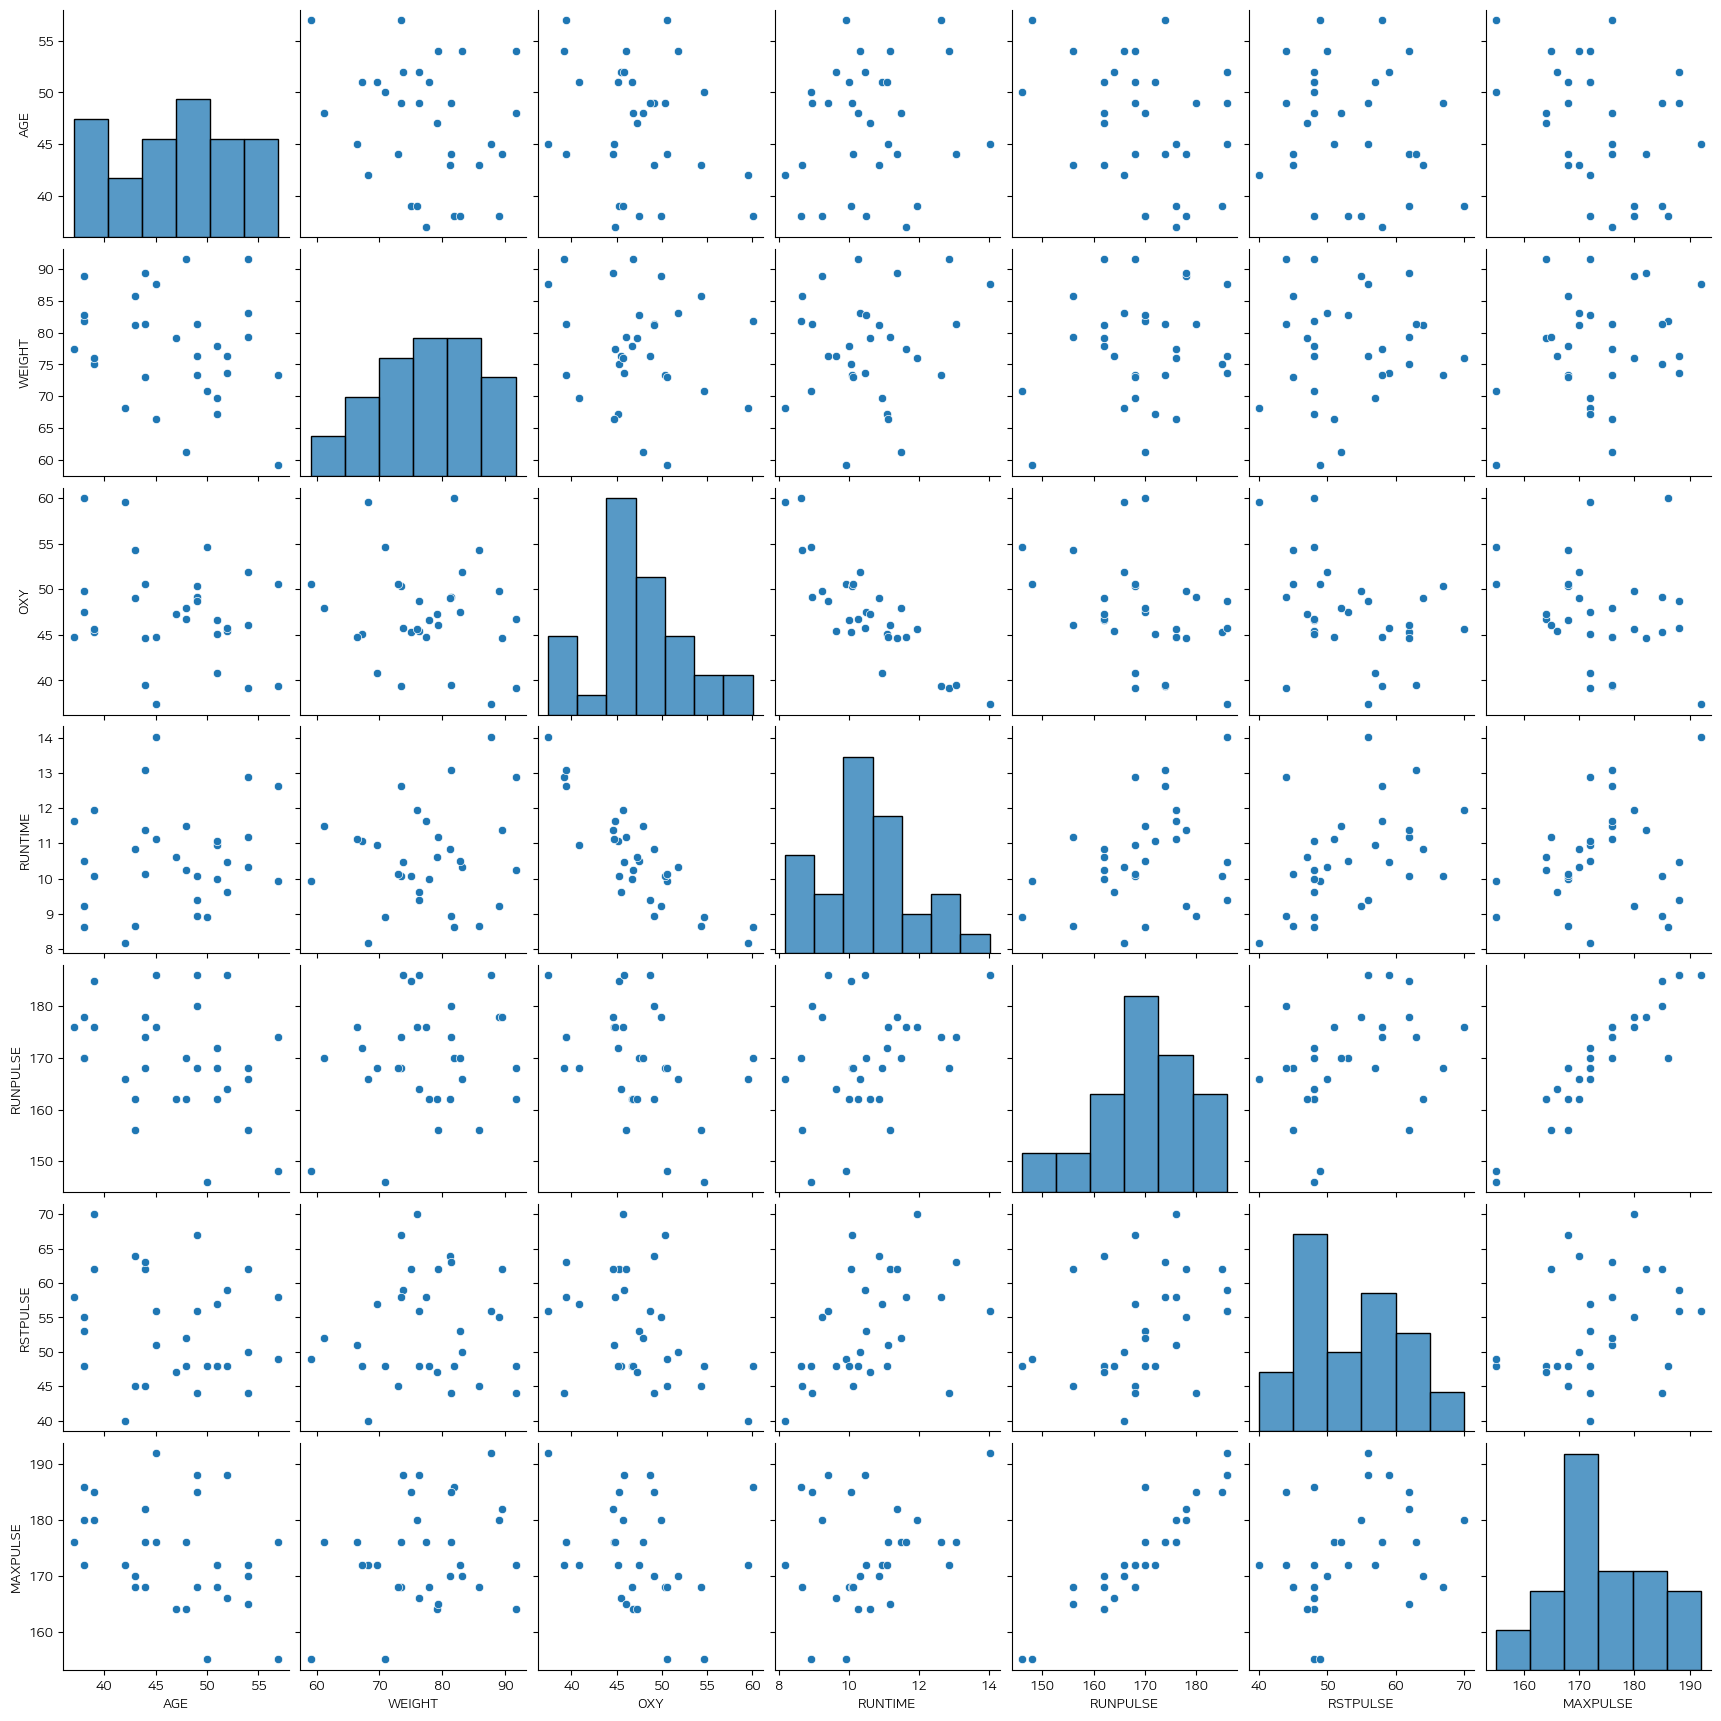

In [59]:
sns.pairplot(df_fitness)

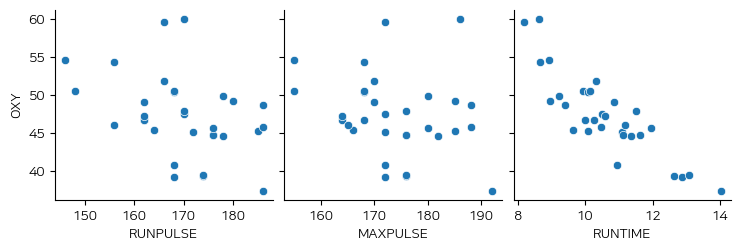

In [62]:
sns.pairplot(df_fitness, y_vars = ["OXY"], x_vars = ["RUNPULSE", "MAXPULSE", "RUNTIME"])

In [63]:
df_currency_pivot = df_currency.pivot(index = "APPL_DATE",columns = "CURRENCY", values = "STD_RATE")
df_currency_pivot.head()

CURRENCY,CNY,JPY,USD
APPL_DATE,,,
2016-01-01,181.48,976.99,1178.0
2016-01-02,181.48,976.99,1178.0
2016-01-03,181.48,976.99,1178.0
2016-01-04,181.10,992.62,1184.0
2016-01-05,181.94,993.00,1185.0


<Axes: xlabel='APPL_DATE'>

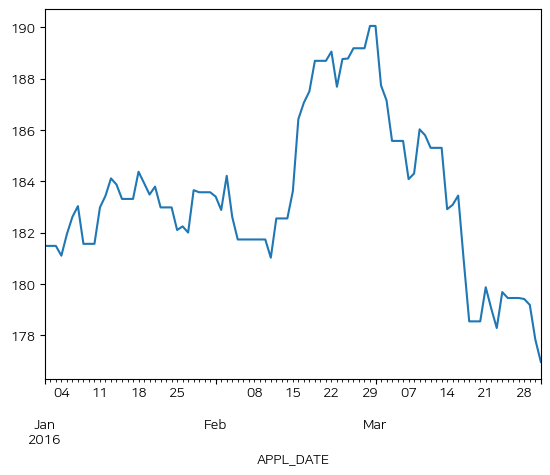

In [64]:
df_currency_pivot["CNY"].plot()

<Axes: xlabel='APPL_DATE'>

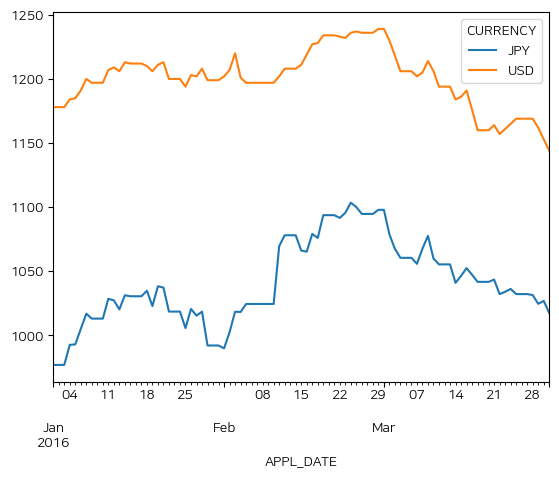

In [65]:
df_currency_pivot[["JPY","USD"]].plot()

/tmp/ipykernel_184384/3063477006.py:2: FutureWarning: In a future version of pandas all arguments of DataFrame.pivot will be keyword-only.
  df_pivot = df_agg.pivot("GENDER","AGEGROUP","OXY")


<Axes: xlabel='AGEGROUP', ylabel='GENDER'>

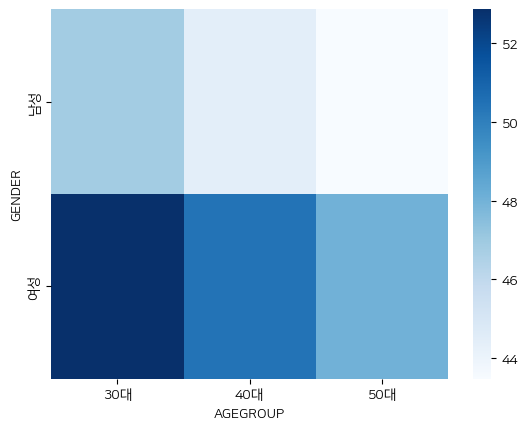

In [71]:
df_agg = df_fitness.groupby(["GENDER","AGEGROUP"], as_index = False)['OXY'].agg("mean")
df_pivot = df_agg.pivot("GENDER","AGEGROUP","OXY")
sns.heatmap(df_pivot, cmap = "Blues")

/tmp/ipykernel_184384/3958814944.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df_corr = df_fitness.corr()


<Axes: >

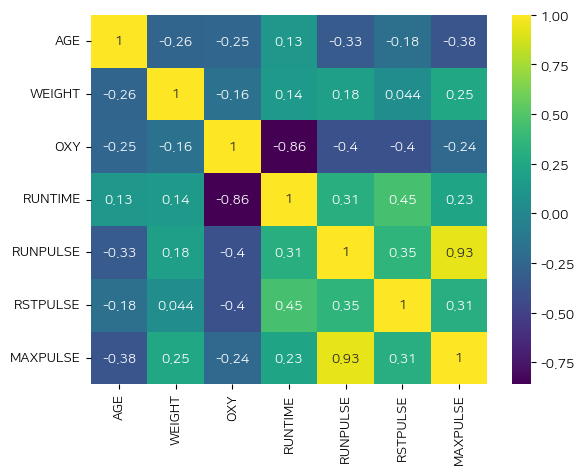

In [75]:
df_corr = df_fitness.corr()
sns.heatmap(df_corr, annot = True, cmap = "viridis")

/tmp/ipykernel_184384/4079172306.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=False`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data = df_fitness, x = "RUNTIME",y = "OXY", shade = False)


<Axes: xlabel='RUNTIME', ylabel='OXY'>

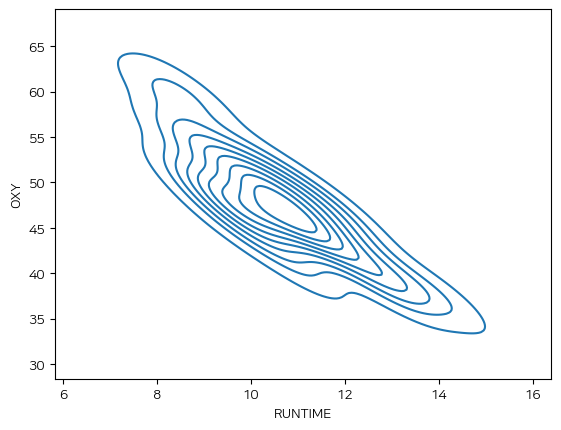

In [76]:
sns.kdeplot(data = df_fitness, x = "RUNTIME",y = "OXY", shade = False)

<Axes: >

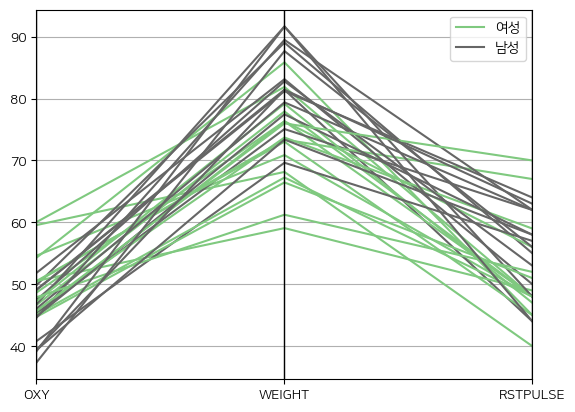

In [77]:
pd.plotting.parallel_coordinates(df_fitness, "GENDER", cols = ["OXY", "WEIGHT", "RSTPULSE"], colormap = "Accent")

Text(676.6426767676767, 0.5, '혈당 산소 요구량')

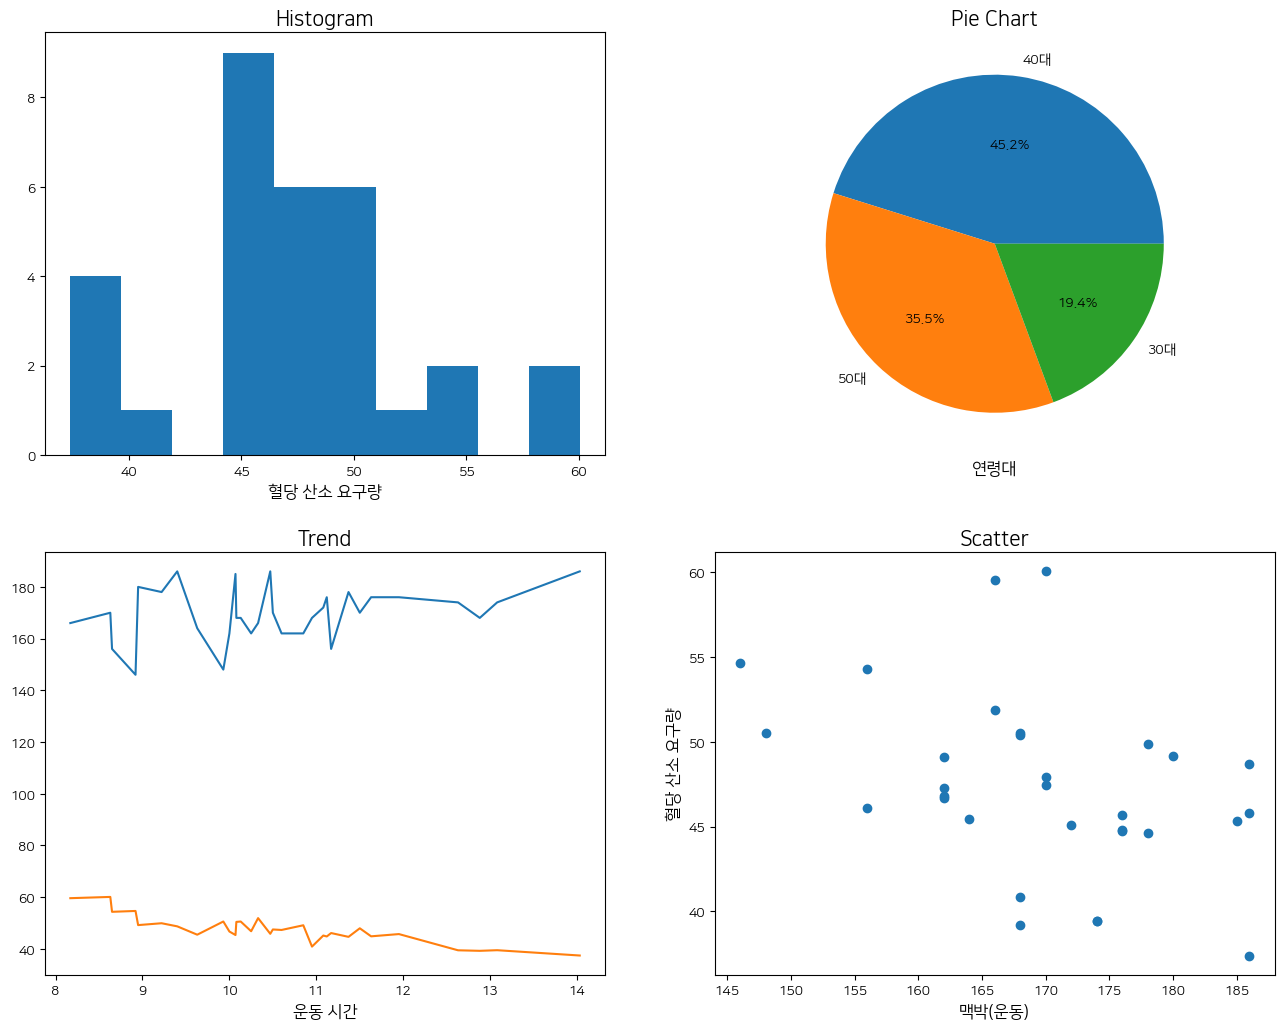

In [81]:
df_count = df_fitness["AGEGROUP"].value_counts()
fig, axes = plt.subplots(nrows=2,ncols=2,figsize = (13,10))
plt.tight_layout(w_pad = 5, h_pad = 5)

axes[0,0].hist(df_fitness["OXY"])
axes[0,0].set_title("Histogram", fontsize = 15)
axes[0,0].set_xlabel("혈당 산소 요구량", fontsize = 12)

axes[0,1].pie(df_count, labels = df_count.index.tolist(), autopct = "%.1f%%")
axes[0,1].set_title("Pie Chart", fontsize = 15)
axes[0,1].set_xlabel("연령대", fontsize = 12)

axes[1,0].plot("RUNTIME", "RUNPULSE", data = df_fitness, label = "맥박(운동)")
axes[1,0].plot("RUNTIME", "OXY", data = df_fitness, label = "혈당 산소 요구량")
axes[1,0].set_title("Trend", fontsize = 15)
axes[1,0].set_xlabel("운동 시간", fontsize = 12)

axes[1,1].scatter("RUNPULSE", "OXY", data = df_fitness)
axes[1,1].set_title("Scatter", fontsize = 15)
axes[1,1].set_xlabel("맥박(운동)", fontsize = 12)
axes[1,1].set_ylabel("혈당 산소 요구량", fontsize = 12)